In [ ]:
# =============================
# 📘 MISSING VALUE IMPUTATION GUIDE (SCIKIT-LEARN)
# =============================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 🔧 Set seed for reproducibility
np.random.seed(42)

# ---------------------------------------
# 🎯 STEP 1: Create Sample DataFrame
# ---------------------------------------
data = {
    'Age': np.random.randint(18, 70, 20),
    'Salary': np.random.randint(30000, 100000, 20),
    'Experience': np.random.randint(0, 20, 20),
}
df = pd.DataFrame(data)

# 🧼 Inject 20% missing values randomly per column
for col in df.columns:
    df.loc[df.sample(frac=0.2, random_state=np.random.randint(100)).index, col] = np.nan

# 🧪 Add a complete column with no NaNs for comparison
df['NoNa'] = np.random.randint(0, 100, 20)

# ---------------------------------------
# ✅ 1. SimpleImputer
# ---------------------------------------
from sklearn.impute import SimpleImputer

# ➕ Add missing indicator columns
si = SimpleImputer(strategy='mean', add_indicator=True)

# ⚙️ Fit and transform data
X_simple = pd.DataFrame(si.fit_transform(df))

# 🔎 SimpleImputer Parameters:
# - strategy: 'mean', 'median', 'most_frequent', 'constant'
# - fill_value: (used with strategy='constant')
# - add_indicator: True adds binary columns for missing flags

# ---------------------------------------
# ✅ 2. KNNImputer
# ---------------------------------------
from sklearn.impute import KNNImputer

knn = KNNImputer(n_neighbors=3)  # 🔁 Use 3 nearest rows to impute missing values
X_knn = pd.DataFrame(knn.fit_transform(df), columns=knn.feature_names_in_)

# 🔎 KNNImputer Parameters:
# - n_neighbors: number of neighbors
# - weights: 'uniform' or 'distance'
# - metric: default is 'nan_euclidean'

# ---------------------------------------
# ✅ 3. MissingIndicator (Add only missing flags)
# ---------------------------------------
from sklearn.impute import MissingIndicator

indicator = MissingIndicator()
missing_flags = pd.DataFrame(indicator.fit_transform(df))

# 🧠 Usually used inside FeatureUnion to combine with imputers
# e.g., FeatureUnion([("imp", SimpleImputer()), ("flags", MissingIndicator())])

# ---------------------------------------
# ✅ 4. Manual (Pandas-based) Imputation
# ---------------------------------------
df['NoAgeNa'] = df['Age']

# Randomly fill NaNs in 'Age' using samples from non-NaN values
df['NoAgeNa'][df['NoAgeNa'].isnull()] = df['Age'].dropna().sample(
    df['NoAgeNa'].isnull().sum(),
    replace=True
).values

# ⚠️ This approach is good for testing or domain-specific logic
# ❌ Not reproducible in pipelines or production ML

# ---------------------------------------
# 📊 KDE Plot to Compare Imputation Effect
# ---------------------------------------

sns.kdeplot(df["Age"], label="Original Age", fill=True)
sns.kdeplot(df["NoAgeNa"], label="Randomly Imputed Age", fill=True)
plt.title("KDE Plot: Original vs Random Imputed 'Age'")
plt.legend()
plt.show()

# ========================================
# 🔚 SUMMARY OF IMPUTATION OPTIONS
# ========================================

# ✔ SimpleImputer     - Fast, flexible (mean/median/mode)
# ✔ KNNImputer        - Learns from neighbors (slower, more context-aware)
# ✔ MissingIndicator  - Adds binary NaN location flags
# ✔ Manual Imputation - Good for custom/random strategies (non-pipelineable)

# 🧠 Combine in pipeline:
# Pipeline([
#     ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
#     ('scaler', StandardScaler()),
#     ('model', LinearRegression())
# ])

# 🧪 Want to benchmark imputers? Use cross-validation with pipeline wrappers!



,Age,Salary,Experience,NoNa
0,56.0,92955.0,8.0,53.0
1,34.8,94925.0,6.0,3.0
2,31.8,97969.0,8.0,53.0
3,32.0,74958.2,3.0,92.0
4,60.0,83707.0,13.0,62.0
5,25.0,58693.0,9.2,17.0
6,38.0,74958.2,8.0,89.0
7,56.0,48431.0,1.0,43.0
8,36.0,32747.0,19.0,33.0
9,40.0,89150.0,14.0,73.0


/tmp/ipython-input-42-2643461514.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['NoAgeNa'][df['NoAgeNa'].isnull()] = df['Age'].dropna().sample(df['NoAgeNa'].isnull().sum()).values
/tmp/ipython-input-42-2643461514.py:1: SettingWithCop

/tmp/ipython-input-50-1262537223.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Age"] , hist = False)
/tmp/ipython-input-50-1262537223.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["NoAgeNa"] , hist = False)


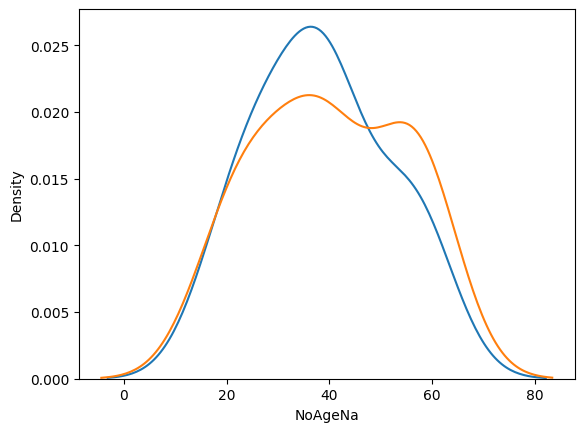

In [ ]:
df.corr()

,Age,Salary,Experience,NoNa,NoAgeNa
Age,1.000000,0.524787,-0.284269,-0.142137,1.000000
Salary,0.524787,1.000000,-0.460038,-0.016360,0.474245
Experience,-0.284269,-0.460038,1.000000,0.175885,-0.276291
NoNa,-0.142137,-0.016360,0.175885,1.000000,0.035476
NoAgeNa,1.000000,0.474245,-0.276291,0.035476,1.000000


,0,1,2,3,4
0,56.000000,92955.000000,8.000000,53.0,56.0
1,29.165018,94925.000000,6.000000,3.0,20.0
2,29.742004,97969.000000,8.089308,53.0,60.0
3,32.000000,70856.954272,3.000000,92.0,32.0
4,60.000000,83707.000000,13.000000,62.0,60.0
5,25.000000,58693.000000,8.557922,17.0,25.0
6,38.000000,75228.808633,8.000000,89.0,38.0
7,56.000000,48431.000000,1.000000,43.0,56.0
8,36.000000,32747.000000,19.000000,33.0,36.0
9,40.000000,89150.000000,14.000000,73.0,40.0
